# Quantum Orthogonal Neural Network Baseline Training on COCO Dataset

This notebook demonstrates training a baseline quantum orthogonal neural network on the COCO dataset without any enhancement techniques like pruning or dropout.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silence INFO and WARNING messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Import our custom model components
import sys
sys.path.append('../src')
from utils.rbs_gate import *

## 1. Data Loading and Preprocessing

Load and preprocess the COCO dataset.

In [2]:
def load_coco_data(data_dir='../data/test2017', num_samples=1000, img_size=(32, 32)):
    """Load and preprocess COCO dataset.
    
    Args:
        data_dir: Directory containing COCO images
        num_samples: Number of samples to load
        img_size: Target image size
    """
    images = []
    labels = []
    
    # Get list of image files
    image_files = [f for f in os.listdir(data_dir) if f.endswith(('.jpg', '.png'))]
    image_files = image_files[:num_samples]
    
    for img_file in tqdm(image_files, desc='Loading images'):
        img_path = os.path.join(data_dir, img_file)
        # Read and preprocess image
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = img_array / 255.0  # Normalize to [0,1]
        
        images.append(img_array)
        # For demonstration, we'll use a binary classification task
        # You can modify this based on your specific needs
        labels.append(np.random.randint(0, 2))
    
    return np.array(images), np.array(labels)

# Load the dataset
X, y = load_coco_data()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)

Loading images: 100%|██████████| 1000/1000 [00:06<00:00, 152.67it/s]


## 2. Baseline Quantum Orthogonal Model

Define a baseline quantum orthogonal neural network without any enhancement techniques.

In [3]:
class BaselineQuantumModel(tf.keras.Model):
    def __init__(self, random_seed=42, wires=6):
        super(BaselineQuantumModel, self).__init__()
        
        # Set seeds for reproducibility
        np.random.seed(random_seed)
        tf.random.set_seed(random_seed)
        qml.numpy.random.seed(random_seed)
        
        self.flatten = tf.keras.layers.Flatten()
        self.dense = tf.keras.layers.Dense(6, activation='linear', dtype=tf.float64)
        self.quantum_weights = self.add_weight(
            shape=(15,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )
        
        # Quantum device with specified number of wires
        self.dev = qml.device('default.qubit.tf', wires=wires)
        
        # Build the quantum node (QNode)
        @qml.qnode(self.dev, interface='tf', diff_method='backprop')
        def quantum_circuit(inputs, weights):
            inputs = tf.cast(inputs, tf.float32)
            weights = tf.cast(weights, tf.float32)
            vector_loader(convert_array(inputs), wires=range(wires))
            pyramid_circuit(weights, wires=range(wires))
            return [qml.expval(qml.PauliZ(wire)) for wire in range(wires)]
        self.quantum_circuit = quantum_circuit
        
        # Additional classical NN layer
        self.classical_nn_2 = tf.keras.layers.Dense(1, activation='sigmoid', dtype=tf.float64)

    def call(self, inputs):
        inputs = tf.cast(inputs, tf.float64)
        flattened_inputs = self.flatten(inputs)
        classical_output = self.dense(flattened_inputs)
        
        # Run quantum circuit for each output from the dense layer
        quantum_outputs = tf.map_fn(
            lambda x: tf.stack(self.quantum_circuit(x, self.quantum_weights)),
            classical_output,
            fn_output_signature=tf.TensorSpec(shape=(6,), dtype=tf.float64)
        )
        # Replace any NaN values with zeros
        quantum_outputs = tf.where(tf.math.is_nan(quantum_outputs), 
                                   tf.zeros_like(quantum_outputs), quantum_outputs)
        quantum_outputs = tf.reshape(quantum_outputs, [-1, 6])
        nn_output = self.classical_nn_2(quantum_outputs)
        return nn_output

## 3. Create and Train the Model

In [9]:
# Create the baseline model
random_seed = 42
model = BaselineQuantumModel(random_seed=random_seed, wires=6)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Training parameters
epochs = 100
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset,
    callbacks=callbacks
)

Epoch 1/100


25/25 [==============================] - 20s 389ms/step - loss: 0.7082 - accuracy: 0.4863 - val_loss: 0.6938 - val_accuracy: 0.4400
Epoch 2/100
25/25 [==============================] - 6s 242ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6939 - val_accuracy: 0.4400
Epoch 3/100
25/25 [==============================] - 7s 272ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6940 - val_accuracy: 0.4400
Epoch 4/100
25/25 [==============================] - 7s 271ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6941 - val_accuracy: 0.4400
Epoch 5/100
25/25 [==============================] - 7s 270ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6941 - val_accuracy: 0.4400
Epoch 6/100
25/25 [==============================] - 7s 260ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6942 - val_accuracy: 0.4400
Epoch 7/100
25/25 [==============================] - 7s 269ms/step - loss: 0.6931 - accuracy: 0.5075 - val_loss: 0.6942 - val_accuracy: 0.4400
Epoch 8/10

## 4. Visualization and Analysis

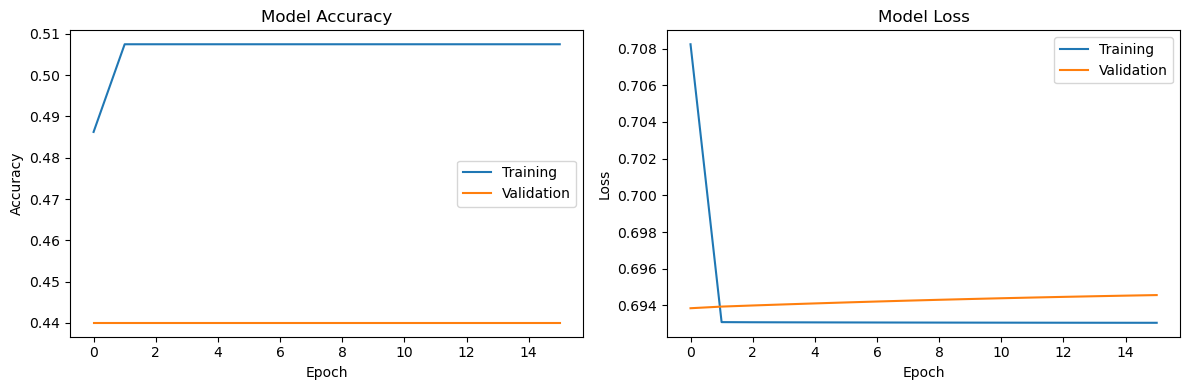

In [11]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

## 5. Model Evaluation

In [7]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest accuracy: {test_accuracy:.4f}")

7/7 [==============================] - 0s 32ms/step - loss: 0.6938 - accuracy: 0.4400

Test accuracy: 0.4400
